In [1]:
import pandas as pd
from google.colab import drive


drive.mount('/content/drive', force_remount = False)

grants = pd.read_csv('/content/drive/MyDrive/M1 Project Proposal/data/grants.csv')
grant_opps = pd.read_csv("/content/drive/MyDrive/M1 Project Proposal/data/grant_opportunity_details.csv")
drugs = pd.read_csv('/content/drive/MyDrive/M1 Project Proposal/data/drugs.csv')

Mounted at /content/drive


/tmp/ipython-input-87266171.py:7: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv('/content/drive/MyDrive/M1 Project Proposal/data/grants.csv')


In [2]:
display(drugs.head())
display(drugs.info())

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

None

In [3]:
import re
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
drugs['condition_indication'] = drugs['condition_indication'].fillna('')

nlp = spacy.load("en_core_web_sm")

def clean_text(text):

    text = str(text).lower()

    replacements = { # condition_indication contains special symbols in words such as CD30+
        '+': 'plus',
        '%': 'percent',
        '>': 'greater',
        '<': 'less',
        '&': 'and',
        '/': 'or'  # 'and/or' becomes 'andor'
    }

    for symbol, word in replacements.items():
        text = text.replace(symbol, word)

    text = text.replace('-', 'minus') # pecial handling for the '-' symbol, as it can be used both as a minus sign and a hyphen
    doc = nlp(text)

    clean_tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct
    ]

    return " ".join(clean_tokens)

drugs["condition_indication_cleaned"] = drugs["condition_indication"].apply(clean_text)
print(f"Original: {drugs['condition_indication'].iloc[0][:100]}")
print(f"Cleaned:  {drugs['condition_indication_cleaned'].iloc[0][:100]}")

Original: Hodgkin lymphomaAdcetris is indicated for adult patients with previously untreated CD30+ Stage IV Ho
Cleaned:  hodgkin lymphomaadcetris indicate adult patient previously untreated cd30plus stage iv hodgkin lymph


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizes the cleaned condition_indication from the previous step for ML modeling later
vectorizer = TfidfVectorizer(max_features = 500, min_df = 0.01, max_df = 0.95) #being generous with 500 words
X_tfidf = vectorizer.fit_transform(drugs["condition_indication_cleaned"])

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns = vectorizer.get_feature_names_out()) #

print("\n--- Vectorization Result ---")
print(f"Matrix Shape: {X_tfidf.shape} (Rows, Unique Words)")
print("Sample of the Vectorized Data:")
print(tfidf_df.iloc[:5, :10])


--- Vectorization Result ---
Matrix Shape: (1988, 500) (Rows, Unique Words)
Sample of the Vectorized Data:
    10        12   15   17   18   30   35        40   75  accord
0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0     0.0
1  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0     0.0
2  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0     0.0
3  0.0  0.260604  0.0  0.0  0.0  0.0  0.0  0.386392  0.0     0.0
4  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0     0.0


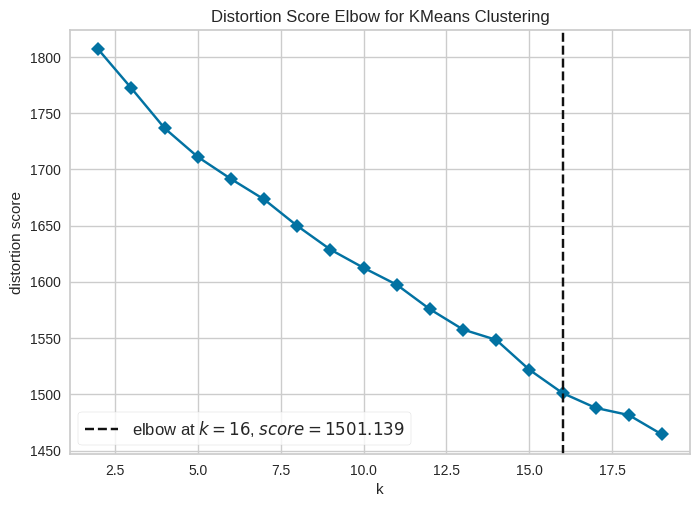

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [5]:
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

k_means = KMeans(random_state = 999, n_init = 10)
visualizer = KElbowVisualizer(k_means, k=(2,20), timings = False)
visualizer.fit(X_tfidf.toarray())
visualizer.show()

Difficult to gauge what the optimal K is with the Elbow Method. Figure shows the biggest 'compromise' points between inertia and K to be between 8-10 (inclusive).

In [6]:
# run K-Means again with set optimal K
optimal_k = 16

kmeans_final = KMeans(n_clusters = optimal_k, random_state = 999, n_init = 16)
kmeans_final.fit(X_tfidf)

drugs['cluster_label'] = kmeans_final.labels_

print(drugs['cluster_label'].value_counts())

cluster_label
15    565
4     220
2     208
5     175
10    173
13    138
0      80
1      73
3      69
11     55
12     53
9      51
7      41
6      34
8      31
14     22
Name: count, dtype: int64


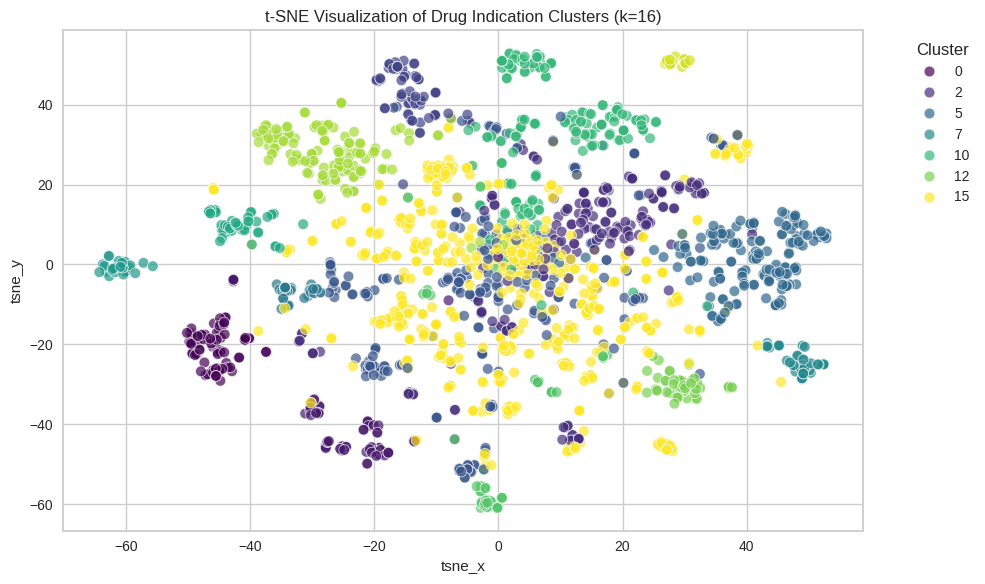

In [18]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components = 2, random_state = 999, init='pca', learning_rate = 'auto')

X_tsne = tsne.fit_transform(X_tfidf.toarray())

drugs['tsne_x'] = X_tsne[:, 0]
drugs['tsne_y'] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=drugs,
    x='tsne_x',
    y='tsne_y',
    hue='cluster_label', # color by the clusters found
    palette='viridis',
    alpha=0.7,
    s=60
)

plt.title(f't-SNE Visualization of Drug Indication Clusters (k={optimal_k})')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

def get_top_keywords(n_terms):
    """This function returns the top keywords for each centroid of the KMeans"""
    drugs_clusters = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
    drugs_clusters['label'] = kmeans_final.labels_

    # group by cluster label, and get the 'mean' of each word.
    cluster_means = drugs_clusters.groupby('label').mean()

    for i, row in cluster_means.iterrows():
        print(f"\nCluster {i}:")
        top_words = row.sort_values(ascending=False).head(n_terms)
        print(", ".join(top_words.index))

print(f"--- Top Keywords for Each Cluster (k={optimal_k}) ---")
get_top_keywords(16)

--- Top Keywords for Each Cluster (k=16) ---

Cluster 0:
metformin, control, glycaemic, diet, exercise, mellitus, diabete, combination, type, adjunct, patient, adequate, diabetes, insulin, sulphonylurea, provide

Cluster 1:
hypertension, essential, pressure, adequately, blood, patient, control, treatment, pulmonary, adult, arterial, disease, indicate, class, combination, mg

Cluster 2:
patient, adult, treatment, indicate, therapy, leukaemia, combination, refractory, lymphoma, prior, cell, monotherapy, disease, receive, myeloma, chronic

Cluster 3:
official, accordance, influenza, recommendation, vaccine, cause, age, year, immunisation, use, individual, active, prophylaxis, the, virus, guidance

Cluster 4:
year, age, treatment, adolescent, indicate, old, patient, adult, child, deficiency, 12, seizure, therapy, paediatric, syndrome, epilepsy

Cluster 5:
cancer, metastatic, advanced, treatment, patient, cell, indicate, locally, combination, chemotherapy, breast, lung, carcinoma, adult, mo

category       human  veterinary
cluster_label                   
0                 80           0
1                 72           1
2                208           0
3                 69           0
4                220           0
5                174           1
6                 34           0
7                 40           1
8                 31           0
9                 51           0
10               171           2
11                55           0
12                53           0
13                 7         131
14                22           0
15               419         146


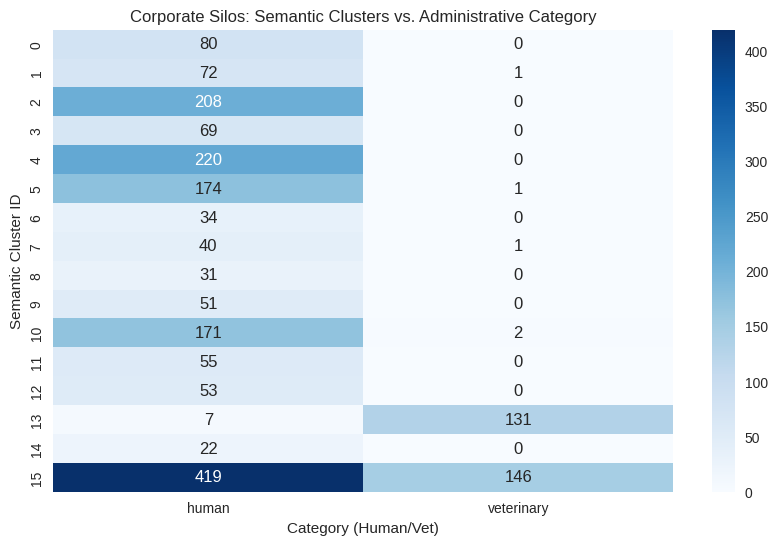

In [17]:
# counts of how many human vs. vet drugs are in each cluster

cluster_species_crosstab = pd.crosstab(drugs['cluster_label'], drugs['category'])
print(cluster_species_crosstab)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_species_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Corporate Silos: Semantic Clusters vs. Administrative Category')
plt.xlabel('Category (Human/Vet)')
plt.ylabel('Semantic Cluster ID')
plt.show()

In [16]:
# calcuating centroids
center_x = drugs['tsne_x'].mean()
center_y = drugs['tsne_y'].mean()

# calculating euclidean distance from centroid
drugs['distance_from_center'] = np.sqrt((drugs['tsne_x'] - center_x)**2 + (drugs['tsne_y'] - center_y)**2)

outliers = drugs.sort_values('distance_from_center', ascending=False).head(10)

print("--- Insight B: The 'Blue Ocean' Outliers ---")
for index, row in outliers.iterrows():
    print(f"Drug: {row['medicine_name']}")
    print(f"Condition: {row['condition_indication'][:100]}...")
    print(f"Cluster: {row['cluster_label']}")
    print("-" * 30)

--- Insight B: The 'Blue Ocean' Outliers ---
Drug: Obizur
Condition: Treatment of bleeding episodes in patients with acquired haemophilia caused by antibodies to Factor ...
Cluster: 8
------------------------------
Drug: NovoSeven
Condition: NovoSeven is indicated for the treatment of bleeding episodes and for the prevention of bleeding in ...
Cluster: 8
------------------------------
Drug: Cevenfacta
Condition: CEVENFACTA is indicated in adults and adolescents (12 years of age and older) for the treatment of b...
Cluster: 8
------------------------------
Drug: Hemlibra
Condition: Hemlibra is indicated for routine prophylaxis of bleeding episodes in patients with haemophilia A (c...
Cluster: 8
------------------------------
Drug: Roctavian
Condition: Treatment of severe haemophilia A (congenital factor VIII deficiency) in adult patients without a hi...
Cluster: 8
------------------------------
Drug: Hemgenix
Condition: Treatment of severe and moderately severe Haemophilia B (congenital